# Types of workflows in LangGraph:
1. Sequential Workflows:
    - The simplest type — steps execute one after another in a fixed order.
    - Use Case:
        1. Data processing pipelines
        2. Simple LLM pipelines (prompt → response → formatting)

2. Parallel Workflows:
    - In a parallel workflow, one node splits into multiple branches that execute simultaneously, and their results are later combined.

3. Conditional/ Branching Workflows:
    - Workflows in which Execution path changes based on conditions
    - Use case:
        1. Decision-making systems
        2. Routing tasks (e.g., different prompts based on user intent)

4. Iterative/ Looping Workflows:
    - The graph can loop back to a previous step until a condition is met
    - Use Case: 
        1. Retry Mechanisms
        2. Multi-Step Reasoning
        3. Agents Refining Answers

### 1. Sequential Workflows

In [ ]:
# BMI Calculator - A simple workflow to calculate BMI and categorize it using LangGraph without LLMs.

from langgraph.graph import StateGraph, START, END
from typing import TypedDict

# 1. Defining state
class BMIState(TypedDict):
    weight_kg: float
    height_m: float
    bmi: float
    category: str

# 2. Defining nodes
def calculate_bmi(state: BMIState) -> BMIState:
    weight = state['weight_kg']
    height = state['height_m']
    bmi = weight/(height**2)

    state['bmi'] = round(bmi, 2)

    return state

def label_bmi(state: BMIState) -> BMIState:
    bmi = state['bmi']

    if bmi < 18.5: state["category"] = "Underweight"
    elif 18.5 <= bmi < 25: state["category"] = "Normal"
    elif 25 <= bmi < 30: state["category"] = "Overweight"
    else: state["category"] = "Obese"

    return state

# 3. Defining  graph
graph = StateGraph(BMIState)

# 4. Adding nodes to your graph
graph.add_node('calculate_bmi', calculate_bmi)
graph.add_node('label_bmi', label_bmi)

# 5. Adding edges to your graph
graph.add_edge(START, 'calculate_bmi')
graph.add_edge('calculate_bmi', 'label_bmi')
graph.add_edge('label_bmi', END)

# 6. Compiling the graph
workflow = graph.compile()

# 7. Executing the graph
initial_state = {'weight_kg':80, 'height_m':1.73}
final_state = workflow.invoke(initial_state)

print(final_state)

{'weight_kg': 80, 'height_m': 1.73, 'bmi': 26.73, 'category': 'Overweight'}


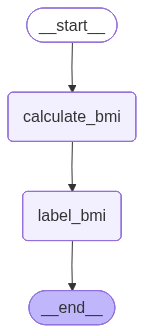

In [2]:
from IPython.display import Image
Image(workflow.get_graph().draw_mermaid_png())

In [ ]:
# LLM QA Workflow - A simple workflow to answer a question using an LLM with LangGraph.

from langgraph.graph import StateGraph, START, END
from langchain_groq import ChatGroq
from typing import TypedDict
from dotenv import load_dotenv

load_dotenv()

model = ChatGroq(model="llama-3.1-8b-instant", temperature=0)

# 1. Defining state
class LLMState(TypedDict):
    question: str
    answer: str

# 2. Defining nodes
def llm_qa(state: LLMState) -> LLMState:
    question = state['question']
    prompt = f'Answer the following question {question}'
    answer = model.invoke(prompt).content

    state['answer'] = answer

    return state

# 3. Defining graph
graph = StateGraph(LLMState)

# 4. Adding nodes
graph.add_node('llm_qa', llm_qa)

# 5. Adding edges
graph.add_edge(START, 'llm_qa')
graph.add_edge('llm_qa', END)

# 6. Compiling the graph
workflow = graph.compile()

# 7. Executing the graph
initial_state = {'question': 'How far is moon from the earth?'}
final_state = workflow.invoke(initial_state)
print(final_state['answer'])

The average distance from the Earth to the Moon is approximately 384,400 kilometers (238,900 miles). This distance is constantly changing due to the elliptical shape of the Moon's orbit around the Earth. At its closest point (called perigee), the Moon is about 363,300 kilometers (225,300 miles) away, and at its farthest point (apogee), it is about 405,500 kilometers (252,000 miles) away.


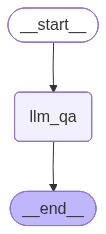

In [4]:
from IPython.display import Image
Image(workflow.get_graph().draw_mermaid_png())

In [ ]:
# Blog Writing Workflow - A workflow to generate a blog outline and then write a blog using that outline with LangGraph and an LLM.
# This workflow is also an example of prompt chaining where the output of one prompt is used in another prompt.

from langgraph.graph import StateGraph, START, END
from langchain_groq import ChatGroq
from typing import TypedDict
from dotenv import load_dotenv

load_dotenv()

model = ChatGroq(model="llama-3.1-8b-instant", temperature=0)

class BlogState(TypedDict):
    title: str
    outline: str
    content: str

def create_outline(state: BlogState) -> BlogState:
    title = state['title']
    prompt = f'Generate a detailed outline for a blog on the topic - {title}'
    outline = model.invoke(prompt).content

    state['outline'] = outline

    return state

def create_blog(state: BlogState) -> BlogState:
    title = state['title']
    outline = state['outline']

    prompt = f'Write a detailed blog on the title - {title} using the follwing outline \n {outline}'
    content = model.invoke(prompt).content

    state['content'] = content

    return state

graph = StateGraph(BlogState)

graph.add_node('create_outline', create_outline)
graph.add_node('create_blog', create_blog)

graph.add_edge(START, 'create_outline')
graph.add_edge('create_outline', 'create_blog')
graph.add_edge('create_blog', END)

workflow = graph.compile()
initial_state = {'title': 'Rise of AI in India'}
final_state = workflow.invoke(initial_state)

print(final_state)

{'title': 'Rise of AI in India', 'outline': "**Title:** The Rise of AI in India: Opportunities, Challenges, and Future Prospects\n\n**I. Introduction**\n\n* Brief overview of the growing importance of Artificial Intelligence (AI) globally\n* Significance of AI in India's economic growth and development\n* Thesis statement: India is poised to become a major player in the AI landscape, driven by government initiatives, technological advancements, and entrepreneurial spirit.\n\n**II. Government Initiatives and Policies**\n\n* Overview of the Indian government's AI strategy and policies\n* Key initiatives:\n\t+ National AI Portal\n\t+ AI for All program\n\t+ AI for Social Good initiative\n\t+ Data Governance Framework\n* Analysis of the impact of these initiatives on the growth of AI in India\n\n**III. Technological Advancements**\n\n* Overview of the key AI technologies being developed in India:\n\t+ Machine Learning (ML)\n\t+ Natural Language Processing (NLP)\n\t+ Computer Vision\n\t+ Ro

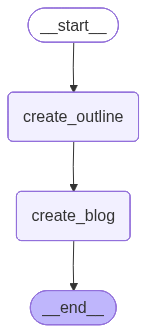

In [7]:
from IPython.display import Image
Image(workflow.get_graph().draw_mermaid_png())

### Parallel Workflows

In [ ]:
# Batsman Performance Analysis Workflow - A workflow to analyze a batsman's performance using LangGraph without LLMs.

from langgraph.graph import StateGraph, START, END
from typing import TypedDict

class BatsmanState(TypedDict):
    runs: int
    balls: int
    fours: int
    sixes: int
    sr: float
    bpb: float
    boundary_percent: float
    summary: str

def calculate_sr(state: BatsmanState):
    sr = (state['runs']/state['balls'])*100
    
    return {'sr': sr}

def calculate_bpb(state: BatsmanState):
    bpb = state['balls']/(state['fours'] + state['sixes'])

    return {'bpb': bpb}

def calculate_boundary_percent(state: BatsmanState):
    boundary_percent = (((state['fours'] * 4) + (state['sixes'] * 6))/state['runs'])*100

    return {'boundary_percent': boundary_percent}

def summary(state: BatsmanState):
    summary = f"""
        Strike Rate - {state['sr']} \n
        Balls per boundary - {state['bpb']} \n
        Boundary percent - {state['boundary_percent']}
        """
    
    return {'summary': summary}

graph = StateGraph(BatsmanState)

graph.add_node('calculate_sr', calculate_sr)
graph.add_node('calculate_bpb', calculate_bpb)
graph.add_node('calculate_boundary_percent', calculate_boundary_percent)
graph.add_node('summary', summary)

# edges
graph.add_edge(START, 'calculate_sr')
graph.add_edge(START, 'calculate_bpb')
graph.add_edge(START, 'calculate_boundary_percent')

graph.add_edge('calculate_sr', 'summary')
graph.add_edge('calculate_bpb', 'summary')
graph.add_edge('calculate_boundary_percent', 'summary')

graph.add_edge('summary', END)

workflow = graph.compile()
intial_state = {
    'runs': 100,
    'balls': 50,
    'fours': 6,
    'sixes': 4
}
workflow.invoke(intial_state)

{'runs': 100,
 'balls': 50,
 'fours': 6,
 'sixes': 4,
 'sr': 200.0,
 'bpb': 5.0,
 'boundary_percent': 48.0,
 'summary': '\n        Strike Rate - 200.0 \n\n        Balls per boundary - 5.0 \n\n        Boundary percent - 48.0\n        '}

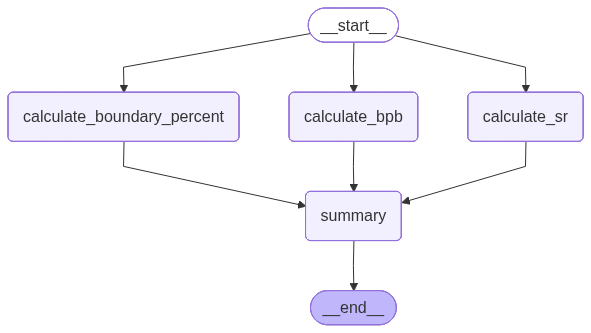

In [17]:
workflow

In [ ]:
# UPSC Essay Evaluation Workflow - A workflow to evaluate an essay based on multiple parameters like language, analysis and clarity using LangGraph and an LLM. This workflow also demonstrates the use of structured outputs from the LLM and how to aggregate them in the final evaluation.

from langgraph.graph import StateGraph, START, END
from langchain_groq import ChatGroq
from dotenv import load_dotenv
from typing import TypedDict, Annotated
from pydantic import BaseModel, Field
import operator

load_dotenv()

model = ChatGroq(model="llama-3.1-8b-instant", temperature=0)

class EvaluationSchema(BaseModel):
    feedback: str = Field(description='Detailed feedbackfor the essay')
    score: int = Field(description='Score out of 10', ge=0, le=10)

class UPSCState(TypedDict):
    essay: str
    language_feedback: str
    analysis_feedback: str
    clarity_feedback: str
    overall_feedback: str
    individual_scores: Annotated[list[int], operator.add]
    avg_score: float

structured_model = model.with_structured_output(EvaluationSchema, method="function_calling")

def evaluate_language(state: UPSCState):
    prompt = f'''
        Evaluate the language quality of the following essay.

        Return the output in JSON format with keys:
        - feedback
        - score (out of 10)

        Essay:
        {state["essay"]}
        '''
    output = structured_model.invoke(prompt)

    return {'language_feedback': output.feedback, 'individual_scores': [output.score]}

def evaluate_analysis(state: UPSCState):
    prompt = f'''
        Evaluate the depth of analysis of the following essay.

        Return the output in JSON format with keys:
        - feedback
        - score (out of 10)

        Essay:
        {state["essay"]}
        '''
    output = structured_model.invoke(prompt)

    return {'analysis_feedback': output.feedback, 'individual_scores': [output.score]}

def evaluate_thought(state: UPSCState):
    prompt = f'''
        Evaluate the clarity of thought of the following essay.

        Return the output in JSON format with keys:
        - feedback
        - score (out of 10)

        Essay:
        {state["essay"]}
        '''
    output = structured_model.invoke(prompt)

    return {'clarity_feedback': output.feedback, 'individual_scores': [output.score]}

def final_evaluation(state: UPSCState):
    prompt = f'''
        Based on the following feedbacks, create a summarized feedback:

        language feedback - {state["language_feedback"]}
        depth of analysis feedback - {state["analysis_feedback"]}
        clarity of thought feedback - {state["clarity_feedback"]}
    '''
    overall_feedback = model.invoke(prompt).content

    avg_score = sum(state['individual_scores'])/len(state['individual_scores'])

    return {'overall_feedback': overall_feedback, 'avg_score': avg_score}
    
graph = StateGraph(UPSCState)

graph.add_node('evaluate_language', evaluate_language)
graph.add_node('evaluate_analysis', evaluate_analysis)
graph.add_node('evaluate_thought', evaluate_thought)
graph.add_node('final_evaluation', final_evaluation)

# edges
graph.add_edge(START, 'evaluate_language')
graph.add_edge(START, 'evaluate_analysis')
graph.add_edge(START, 'evaluate_thought')

graph.add_edge('evaluate_language', 'final_evaluation')
graph.add_edge('evaluate_analysis', 'final_evaluation')
graph.add_edge('evaluate_thought', 'final_evaluation')

graph.add_edge('final_evaluation', END)

workflow = graph.compile()

essay = """India in the Age of AI
            As the world enters a transformative era defined by artificial intelligence (AI), India stands at a critical juncture — one where it can either emerge as a global leader in AI innovation or risk falling behind in the technology race. The age of AI brings with it immense promise as well as unprecedented challenges, and how India navigates this landscape will shape its socio-economic and geopolitical future.
            India's strengths in the AI domain are rooted in its vast pool of skilled engineers, a thriving IT industry, and a growing startup ecosystem. With over 5 million STEM graduates annually and a burgeoning base of AI researchers, India possesses the intellectual capital required to build cutting-edge AI systems. Institutions like IITs, IIITs, and IISc have begun fostering AI research, while private players such as TCS, Infosys, and Wipro are integrating AI into their global services. In 2020, the government launched the National AI Strategy (AI for All) with a focus on inclusive growth, aiming to leverage AI in healthcare, agriculture, education, and smart mobility.
            One of the most promising applications of AI in India lies in agriculture, where predictive analytics can guide farmers on optimal sowing times, weather forecasts, and pest control. In healthcare, AI-powered diagnostics can help address India’s doctor-patient ratio crisis, particularly in rural areas. Educational platforms are increasingly using AI to personalize learning paths, while smart governance tools are helping improve public service delivery and fraud detection.
            However, the path to AI-led growth is riddled with challenges. Chief among them is the digital divide. While metropolitan cities may embrace AI-driven solutions, rural India continues to struggle with basic internet access and digital literacy. The risk of job displacement due to automation also looms large, especially for low-skilled workers. Without effective skilling and re-skilling programs, AI could exacerbate existing socio-economic inequalities.
            Another pressing concern is data privacy and ethics. As AI systems rely heavily on vast datasets, ensuring that personal data is used transparently and responsibly becomes vital. India is still shaping its data protection laws, and in the absence of a strong regulatory framework, AI systems may risk misuse or bias.
            To harness AI responsibly, India must adopt a multi-stakeholder approach involving the government, academia, industry, and civil society. Policies should promote open datasets, encourage responsible innovation, and ensure ethical AI practices. There is also a need for international collaboration, particularly with countries leading in AI research, to gain strategic advantage and ensure interoperability in global systems.
            India’s demographic divideAnd, when paired with responsible AI adoption, can unlock massive economic growth, improve governance, and uplift marginalized communities. But this vision will only materialize if AI is seen not merely as a tool for automation, but as an enabler of human-centered development.
            In conclusion, India in the age of AI is a story in the making — one of opportunity, responsibility, and transformation. The decisions we make today will not just determine India’s AI trajectory, but also its future as an inclusive, equitable, and innovation-driven society.
            """

initial_state = {'essay': essay}
workflow.invoke(initial_state)

{'essay': "India in the Age of AI\n            As the world enters a transformative era defined by artificial intelligence (AI), India stands at a critical juncture — one where it can either emerge as a global leader in AI innovation or risk falling behind in the technology race. The age of AI brings with it immense promise as well as unprecedented challenges, and how India navigates this landscape will shape its socio-economic and geopolitical future.\n            India's strengths in the AI domain are rooted in its vast pool of skilled engineers, a thriving IT industry, and a growing startup ecosystem. With over 5 million STEM graduates annually and a burgeoning base of AI researchers, India possesses the intellectual capital required to build cutting-edge AI systems. Institutions like IITs, IIITs, and IISc have begun fostering AI research, while private players such as TCS, Infosys, and Wipro are integrating AI into their global services. In 2020, the government launched the Nationa

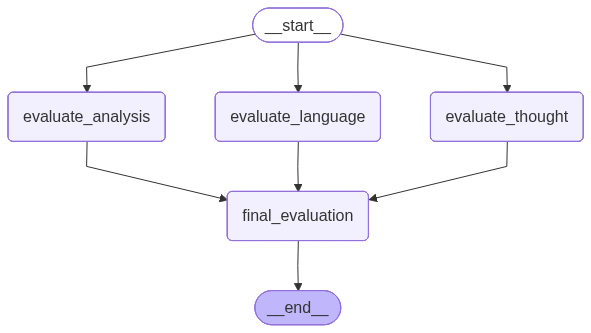

In [10]:
workflow

### Conditional Workflows

In [ ]:
# Customer Review Response Workflow - A workflow to analyze a customer review, determine its sentiment, diagnose the issue if it's negative, and respond accordingly using LangGraph and an LLM. This workflow also demonstrates the use of structured outputs from the LLM and conditional branching in the graph.

from langgraph.graph import StateGraph, START, END
from langchain_groq import ChatGroq
from typing import TypedDict, Literal
from dotenv import load_dotenv
from pydantic import BaseModel, Field

load_dotenv()
model = ChatGroq(model="llama-3.1-8b-instant", temperature=0)

class SentimentSchema(BaseModel):
    sentiment: Literal["positive", "negative"] = Field(description='Sentiment of the review')

class DiagnosisSchema(BaseModel):
    issue_type: Literal["UX", "Performance", "Bug", "Support", "Other"] = Field(description='The category of issue mentioned in the review')
    tone: Literal["angry", "frustrated", "disappointed", "calm"] = Field(description='The emotional tone expressed by the user')
    urgency: Literal["low", "medium", "high"] = Field(description='How urgent or critical the issue appears to be')

structured_model = model.with_structured_output(SentimentSchema)
structured_model2 = model.with_structured_output(DiagnosisSchema)

class ReviewState(TypedDict):
    review: str
    sentiment: Literal["positive", "negative"]
    diagnosis: dict
    response: str

def find_sentiment(state: ReviewState):
    prompt = f'For the following review find out the sentiment \n {state["review"]}'
    sentiment = structured_model.invoke(prompt).sentiment

    return {'sentiment': sentiment}

def check_sentiment(state: ReviewState) -> Literal["positive_response", "run_diagnosis"]:
    if state['sentiment'] == 'positive':
        return 'positive_response'
    else:
        return 'run_diagnosis'
    
def positive_response(state: ReviewState):
    prompt = f"""Write a warm thank-you message in response to this review:
            \n\n\"{state['review']}\"\n
        Also, kindly ask the user to leave feedback on our website."""
            
    response = model.invoke(prompt).content

    return {'response': response}

def run_diagnosis(state: ReviewState):
    prompt = f"""Diagnose this negative review:\n\n{state['review']}\n"
            "Return issue_type, tone, and urgency.
        """

    response = structured_model2.invoke(prompt)

    return {'diagnosis': response.model_dump()}

def negative_response(state: ReviewState):
    diagnosis = state['diagnosis']
    prompt = f"""You are a support assistant.
        The user had a '{diagnosis['issue_type']}' issue, sounded '{diagnosis['tone']}', and marked urgency as '{diagnosis['urgency']}'.
        Write an empathetic, helpful resolution message.
        """
    response = model.invoke(prompt).content

    return {'response': response}
    
graph = StateGraph(ReviewState)

graph.add_node('find_sentiment', find_sentiment)
graph.add_node('positive_response', positive_response)
graph.add_node('run_diagnosis', run_diagnosis)
graph.add_node('negative_response', negative_response)

graph.add_edge(START, 'find_sentiment')

graph.add_conditional_edges('find_sentiment', check_sentiment)

graph.add_edge('positive_response', END)
graph.add_edge('run_diagnosis', 'negative_response')
graph.add_edge('negative_response', END)

workflow = graph.compile()

intial_state={'review': "I’ve been trying to log in for over an hour now, and the app keeps freezing on the authentication screen. I even tried reinstalling it, but no luck. This kind of bug is unacceptable, especially when it affects basic functionality."}
workflow.invoke(intial_state)

{'review': 'I’ve been trying to log in for over an hour now, and the app keeps freezing on the authentication screen. I even tried reinstalling it, but no luck. This kind of bug is unacceptable, especially when it affects basic functionality.',
 'sentiment': 'negative',
 'diagnosis': {'issue_type': 'Bug', 'tone': 'angry', 'urgency': 'high'},
 'response': "Dear [User],\n\nI'm so sorry to hear that you're experiencing a 'Bug' issue with our system. I can imagine how frustrating that must be for you, and I want to assure you that I'm here to help resolve the problem as quickly as possible.\n\nI've taken note of your urgency level as 'High', and I'll do my best to expedite the process. Please know that I'm committed to finding a solution for you and getting you back up and running smoothly.\n\nTo better understand the issue, could you please provide me with more details about the bug you're experiencing? For example, what exactly is happening, and when did it start? This information will h

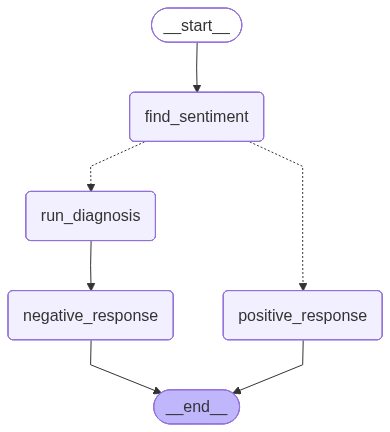

In [12]:
workflow

### Iterative Workflows

In [ ]:
import operator
from langchain_groq import ChatGroq
from pydantic import BaseModel, Field
from typing import TypedDict, Literal, Annotated
from langgraph.graph import StateGraph,START, END
from langchain_core.messages import SystemMessage, HumanMessage

generator_llm = ChatGroq(model="llama-3.1-8b-instant", temperature=0)
evaluator_llm = ChatGroq(model="llama-3.1-8b-instant", temperature=0)
optimizer_llm = ChatGroq(model="llama-3.1-8b-instant", temperature=0)

class TweetEvaluation(BaseModel):
    evaluation: Literal["approved", "needs_improvement"] = Field(..., description="Final evaluation result.")
    feedback: str = Field(..., description="feedback for the tweet.")

structured_evaluator_llm = evaluator_llm.with_structured_output(TweetEvaluation)

class TweetState(TypedDict):
    topic: str
    tweet: str
    evaluation: Literal["approved", "needs_improvement"]
    feedback: str
    iteration: int
    max_iteration: int
    tweet_history: Annotated[list[str], operator.add]
    feedback_history: Annotated[list[str], operator.add]

def generate_tweet(state: TweetState):
    messages = [
        SystemMessage(content="You are a funny and clever Twitter/X influencer."),
        HumanMessage(content=f"""
            Write a short, original, and hilarious tweet on the topic: "{state['topic']}".

            Rules:
            - Do NOT use question-answer format.
            - Max 280 characters.
            - Use observational humor, irony, sarcasm, or cultural references.
            - Think in meme logic, punchlines, or relatable takes.
            - Use simple, day to day english
            """)
                ]

    response = generator_llm.invoke(messages).content

    return {'tweet': response, 'tweet_history': [response]}

def evaluate_tweet(state: TweetState):
    messages = [
    SystemMessage(content="You are a ruthless, no-laugh-given Twitter critic. You evaluate tweets based on humor, originality, virality, and tweet format."),
    HumanMessage(content=f"""
        Evaluate the following tweet:

        Tweet: "{state['tweet']}"

        Use the criteria below to evaluate the tweet:

        1. Originality – Is this fresh, or have you seen it a hundred times before?  
        2. Humor – Did it genuinely make you smile, laugh, or chuckle?  
        3. Punchiness – Is it short, sharp, and scroll-stopping?  
        4. Virality Potential – Would people retweet or share it?  
        5. Format – Is it a well-formed tweet (not a setup-punchline joke, not a Q&A joke, and under 280 characters)?

        Auto-reject if:
        - It's written in question-answer format (e.g., "Why did..." or "What happens when...")
        - It exceeds 280 characters
        - It reads like a traditional setup-punchline joke
        - Dont end with generic, throwaway, or deflating lines that weaken the humor (e.g., “Masterpieces of the auntie-uncle universe” or vague summaries)

        ### Respond ONLY in structured format:
        - evaluation: "approved" or "needs_improvement"  
        - feedback: One paragraph explaining the strengths and weaknesses 
        """)
        ]

    response = structured_evaluator_llm.invoke(messages)

    return {'evaluation':response.evaluation, 'feedback': response.feedback, 'feedback_history': [response.feedback]}

def optimize_tweet(state: TweetState):
    messages = [
        SystemMessage(content="You punch up tweets for virality and humor based on given feedback."),
        HumanMessage(content=f"""
            Improve the tweet based on this feedback:
            "{state['feedback']}"

            Topic: "{state['topic']}"
            Original Tweet:
            {state['tweet']}

            Re-write it as a short, viral-worthy tweet. Avoid Q&A style and stay under 280 characters.
            """)
                ]
    response = optimizer_llm.invoke(messages).content
    iteration = state['iteration'] + 1

    return {'tweet': response, 'iteration': iteration, 'tweet_history': [response]}

def route_evaluation(state: TweetState):
    if state['evaluation'] == 'approved' or state['iteration'] >= state['max_iteration']:
        return 'approved'
    else:
        return 'needs_improvement'

graph = StateGraph(TweetState)

graph.add_node('generate', generate_tweet)
graph.add_node('evaluate', evaluate_tweet)
graph.add_node('optimize', optimize_tweet)

graph.add_edge(START, 'generate')
graph.add_edge('generate', 'evaluate')

graph.add_conditional_edges('evaluate', route_evaluation, {'approved': END, 'needs_improvement': 'optimize'})
graph.add_edge('optimize', 'evaluate')

workflow = graph.compile()
initial_state = {
    "topic": "India's population",
    "iteration": 1,s
    "max_iteration": 5
}
result = workflow.invoke(initial_state)
result


{'topic': "India's population",
 'tweet': '"India\'s population is like a never-ending Bollywood dance party - everyone\'s dancing, but nobody\'s leaving the floor #IndiaPopulation #BollywoodVibes"',
 'evaluation': 'approved',
 'feedback': "This tweet is well-crafted and effectively uses a clever analogy to describe India's population. The use of 'Bollywood dance party' is original and engaging, and the hashtag adds a touch of creativity. However, the humor is somewhat subtle and may not appeal to everyone. Nevertheless, the tweet's brevity, clarity, and potential for virality make it a strong contender. To further improve, consider adding a more unexpected twist or punchline to elevate the humor.",
 'iteration': 1,
 'max_iteration': 5,
 'tweet_history': ['"India\'s population is like a never-ending Bollywood dance party - everyone\'s dancing, but nobody\'s leaving the floor #IndiaPopulation #BollywoodVibes"'],
 'feedback_history': ["This tweet is well-crafted and effectively uses a cl

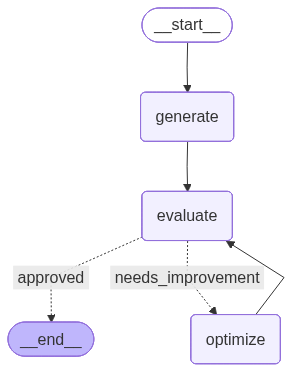

In [14]:
workflow